# Šum u podacima (Dealing with Noisy Data)

U praksi mašinskog učenja podaci često sadrže različite nepravilnosti koje mogu negativno uticati na performanse modela. Takve nepravilnosti se zajednički nazivaju šum u podacima.

Prisustvo šuma može dovesti do lošijeg učenja modela, povećanja greške i smanjene mogućnosti generalizacije. Zbog toga je identifikacija i obrada šuma jedan od ključnih koraka u fazi pripreme podataka.

Cilj ovog praktičnog dela je da se, na realnom skupu podataka o kvalitetu vazduha, prikaže kompletan tok rada u mašinskom učenju:
- učitavanje i inicijalna analiza podataka,
- čišćenje podataka (posebno tretman nedostajućih vrednosti),
- definisanje problema (izbor ciljne promenljive / target-a),
- uspostavljanje **baseline** modela,
- primena izabranih tehnika i modela,
- poređenje rezultata sa baseline pristupom.

## Skup podataka
Koristi se skup podataka „Air Quality” (poznat i kao UCI AirQuality), preuzet preko Kaggle repozitorijuma, koji sadrži:
- merenja zagađujućih gasova (npr. CO, NOx, NO2) i očitavanja senzora,
- meteorološke promenljive (temperatura, relativna vlažnost, apsolutna vlažnost),
- vremenska komponenta (datum i vreme merenja).

Skup podataka je pogodan za ovaj zadatak jer sadrži:
- neispravna merenja označena sentinel vrednošću **-200**,
- nedostajuće vrednosti,
- potencijalne ekstremne vrednosti.

Ove karakteristike omogućavaju jasno poređenje rezultata modela pre i nakon obrade šuma.

U ovom radu problem tretiramo kao **regresioni zadatak**:
**predviđanje koncentracije CO (kolona `CO(GT)`) na osnovu ostalih dostupnih obeležja.**

## Plan eksperimenta
1. Učitavanje i pregled podataka  
2. Čišćenje i obrada nedostajućih vrednosti  
3. Podela na trening i test (uz poštovanje vremenskog redosleda)  
4. Baseline model i baseline rezultati  
5. Poboljšanja: imputacija + skaliranje + izbor modela / selekcija obeležja  
6. Uporedna analiza i zaključak


In [263]:
import numpy as np
import pandas as pd

import sklearn
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import KNNImputer

import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

## Učitavanje i osnovni pregled podataka

U ovoj sekciji učitava se skup podataka iz CSV fajla i vrši se osnovni pregled:
- dimenzije skupa podataka,
- nazivi i tipovi kolona,
- primeri redova,
- osnovne statističke karakteristike numeričkih obeležja.

Ovaj korak omogućava bolje razumevanje strukture podataka i identifikaciju potencijalnih problema, kao što su nedostajuće ili nekonzistentne vrednosti.


In [171]:
data_path = "data/AirQualityUCI.csv"

df = pd.read_csv(data_path, sep=";",decimal=",")

df = df.dropna(axis=1, how="all")

df.shape

(9471, 15)

In [172]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(13), object(2)
memory usage: 1.1+ MB


In [174]:
df.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


In [175]:
df.dtypes

Date              object
Time              object
CO(GT)           float64
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
dtype: object

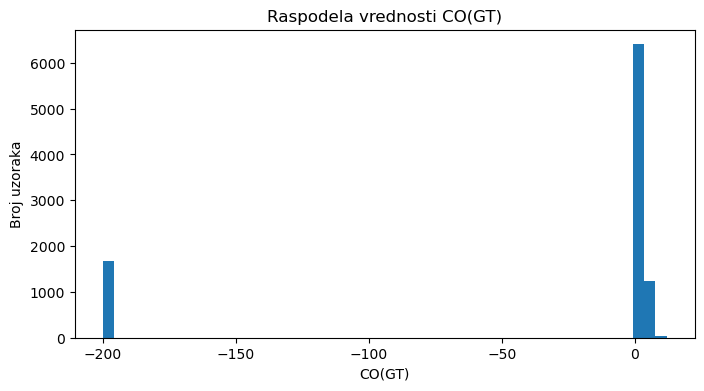

In [176]:
plt.figure(figsize=(8, 4))
plt.hist(df["CO(GT)"], bins=50)
plt.xlabel("CO(GT)")
plt.ylabel("Broj uzoraka")
plt.title("Raspodela vrednosti CO(GT)")
plt.show()

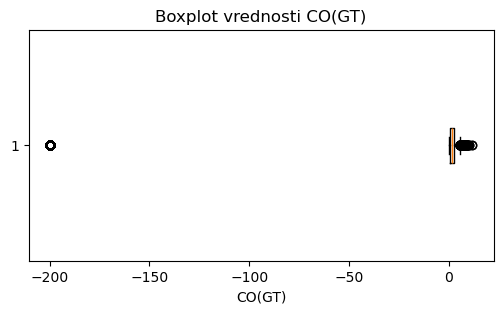

In [177]:
plt.figure(figsize=(6, 3))
plt.boxplot(df["CO(GT)"].dropna(), vert=False)
plt.xlabel("CO(GT)")
plt.title("Boxplot vrednosti CO(GT)")
plt.show()

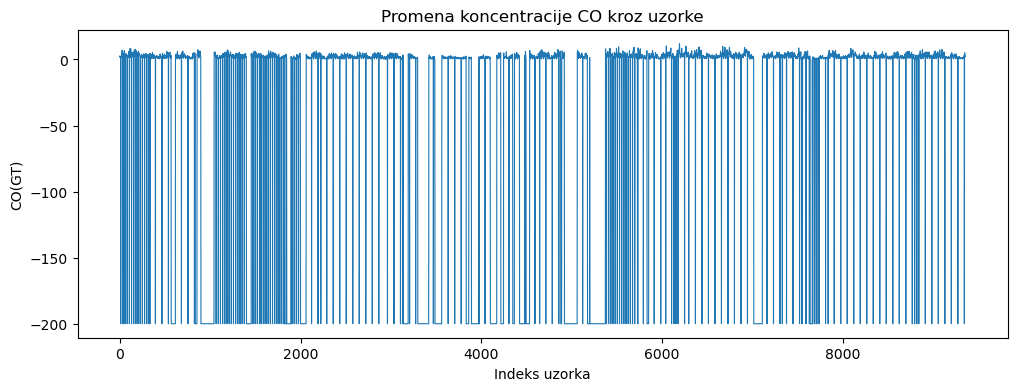

In [286]:
vxdf = df[df["CO(GT)"].notna()]

plt.figure(figsize=(12,4))
plt.plot(vxdf.index, vxdf["CO(GT)"], linewidth=0.8)

plt.xlabel("Indeks uzorka")
plt.ylabel("CO(GT)")
plt.title("Promena koncentracije CO kroz uzorke")
plt.show()

## Identifikacija neispravnih vrednosti

Kod senzorskih podataka neispravna merenja su često označena posebnom numeričkom vrednošću. 
U ovom skupu podataka vrednost **-200** predstavlja takva merenja.

U nastavku se proverava učestalost ove vrednosti u numeričkim kolonama.

In [178]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
(df[numeric_cols] == -200).sum()

CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64

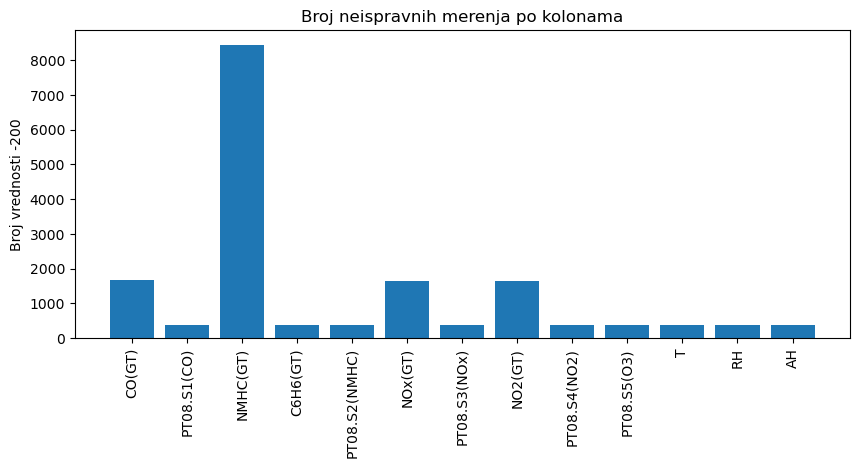

In [179]:
sentinel_counts = (df[numeric_cols] == -200).sum()
sentinel_counts = sentinel_counts[sentinel_counts > 0]

plt.figure(figsize=(10, 4))
plt.bar(sentinel_counts.index, sentinel_counts.values)
plt.xticks(rotation=90)
plt.ylabel("Broj vrednosti -200")
plt.title("Broj neispravnih merenja po kolonama")
plt.show()

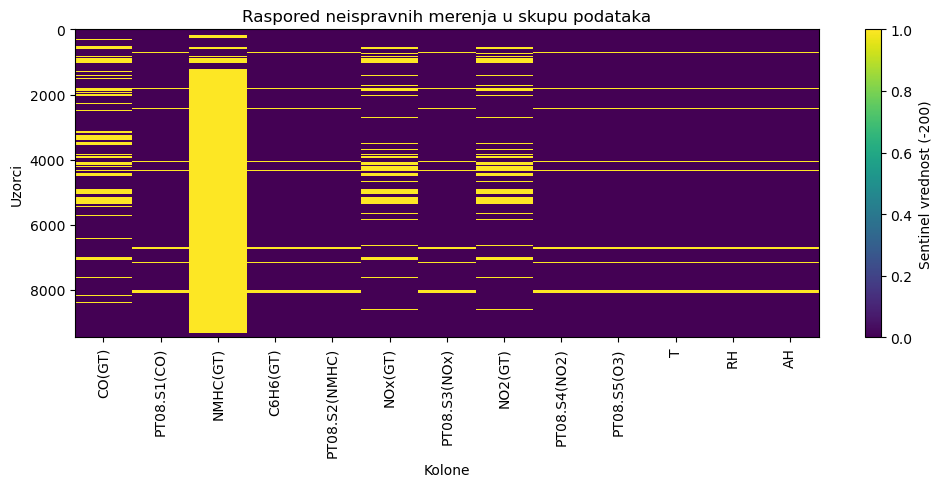

In [180]:
sentinel_mask = (df[numeric_cols] == -200)

plt.figure(figsize=(12, 4))
plt.imshow(sentinel_mask, aspect="auto", interpolation="nearest")
plt.colorbar(label="Sentinel vrednost (-200)")
plt.xlabel("Kolone")
plt.ylabel("Uzorci")
plt.title("Raspored neispravnih merenja u skupu podataka")
plt.xticks(ticks=range(len(numeric_cols)), labels=numeric_cols, rotation=90)
plt.show()

Grafikon pokazuje da su neispravna merenja prisutna u većem broju kolona, što potvrđuje potrebu za obradom šuma pre treniranja modela.

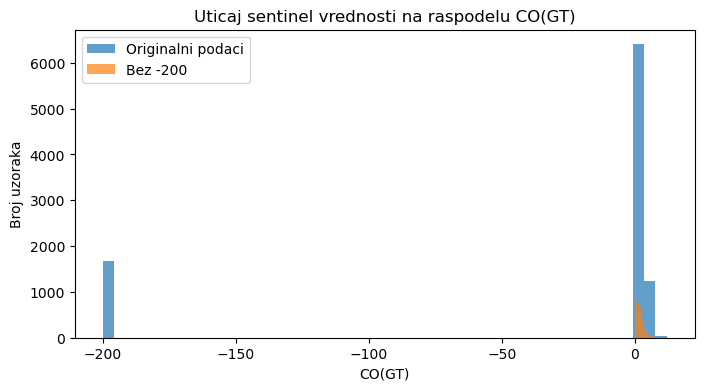

In [181]:
valid_values = df["CO(GT)"][df["CO(GT)"] != -200]

plt.figure(figsize=(8, 4))
plt.hist(df["CO(GT)"], bins=50, alpha=0.7, label="Originalni podaci")
plt.hist(valid_values, bins=50, alpha=0.7, label="Bez -200")
plt.legend()
plt.xlabel("CO(GT)")
plt.ylabel("Broj uzoraka")
plt.title("Uticaj sentinel vrednosti na raspodelu CO(GT)")
plt.show()

U sledećem koraku proverava se broj nedostajućih (NaN) vrednosti po kolonama kako bi se utvrdilo da li dataset sadrži eksplicitno označene missing vrednosti.

In [182]:
df.isna().sum()

Date             114
Time             114
CO(GT)           114
PT08.S1(CO)      114
NMHC(GT)         114
C6H6(GT)         114
PT08.S2(NMHC)    114
NOx(GT)          114
PT08.S3(NOx)     114
NO2(GT)          114
PT08.S4(NO2)     114
PT08.S5(O3)      114
T                114
RH               114
AH               114
dtype: int64

Iz rezultata se može uočiti da dataset ne sadrži ili sadrži veoma mali broj eksplicitnih missing vrednosti, što je tipično za senzorske podatke kod kojih se neispravna merenja često označavaju posebnom numeričkom vrednošću.

In [184]:
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("Ukupno NaN u df_base:", df.isna().sum().sum())
df.head()

Ukupno NaN u df_base: 1482


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


## Uklanjanje nerelevantnih kolona

Skup podataka sadrži kolone koje ne nose informaciju korisnu za treniranje modela, kao što su datum i vreme merenja. 
Ove kolone se uklanjaju kako bi se model trenirao isključivo na numeričkim obeležjima.


In [183]:
df = df.drop(columns=["Date", "Time"], errors="ignore")
df.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


## Provera konstantnih kolona

Kolone koje imaju istu ili gotovo istu vrednost u većini uzoraka ne doprinose učenju modela i mogu se smatrati oblikom šuma.

U nastavku se proverava broj jedinstvenih vrednosti po kolonama.


In [149]:
df.nunique().sort_values()

CO(GT)             97
NO2(GT)           284
C6H6(GT)          408
NMHC(GT)          430
T                 437
RH                754
NOx(GT)           926
PT08.S1(CO)      1042
PT08.S3(NOx)     1222
PT08.S2(NMHC)    1246
PT08.S4(NO2)     1604
PT08.S5(O3)      1744
AH               6684
dtype: int64

In [150]:
(df.nunique() <= 1)

CO(GT)           False
PT08.S1(CO)      False
NMHC(GT)         False
C6H6(GT)         False
PT08.S2(NMHC)    False
NOx(GT)          False
PT08.S3(NOx)     False
NO2(GT)          False
PT08.S4(NO2)     False
PT08.S5(O3)      False
T                False
RH               False
AH               False
dtype: bool

## Odnos obeležja i ciljne promenljive

Pre treniranja modela proverava se povezanost ulaznih obeležja sa ciljnom promenljivom CO(GT). 
Ovaj korak služi za osnovni uvid u informativnost dostupnih obeležja.


In [151]:
correlations = df.corr()["CO(GT)"].sort_values(ascending=False)
correlations

CO(GT)           1.000000
NO2(GT)          0.671127
NOx(GT)          0.526451
NMHC(GT)         0.128351
PT08.S5(O3)      0.080310
PT08.S1(CO)      0.041411
PT08.S2(NMHC)    0.029926
C6H6(GT)        -0.031378
AH              -0.045892
RH              -0.048227
T               -0.068939
PT08.S4(NO2)    -0.073724
PT08.S3(NOx)    -0.089981
Name: CO(GT), dtype: float64

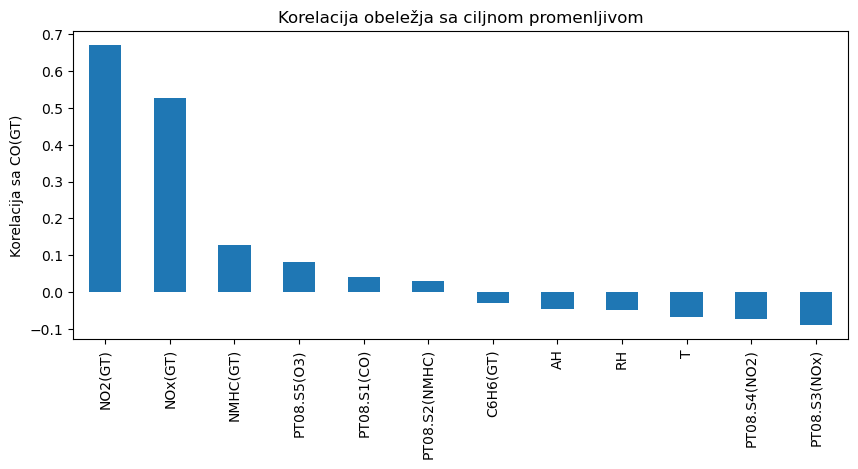

In [152]:
correlations.drop("CO(GT)").plot(kind="bar", figsize=(10, 4))
plt.ylabel("Korelacija sa CO(GT)")
plt.title("Korelacija obeležja sa ciljnom promenljivom")
plt.show()

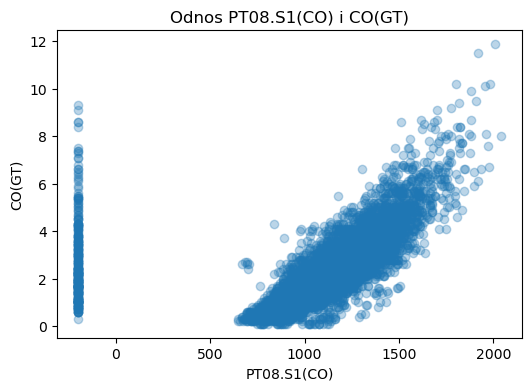

In [153]:
valid_data = df[df["CO(GT)"] != -200]

plt.figure(figsize=(6, 4))
plt.scatter(valid_data["PT08.S1(CO)"], valid_data["CO(GT)"], alpha=0.3)
plt.xlabel("PT08.S1(CO)")
plt.ylabel("CO(GT)")
plt.title("Odnos PT08.S1(CO) i CO(GT)")
plt.show()


## Definisanje ciljne promenljive

U ovom radu ciljna promenljiva je koncentracija ugljen-monoksida, predstavljena kolonom `CO(GT)`.


In [154]:
df.columns

Index(['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH'], dtype='object')

In [155]:
target = "CO(GT)"

features = [col for col in df.columns if col not in [target, "datetime"]]

X = df[features]
y = df[target]

X.shape, y.shape

((9471, 12), (9471,))

## Definisanje zadatka

U ovom radu problem se tretira kao **regresioni zadatak**:  
**predviđanje koncentracije CO (kolona `CO(GT)`) na osnovu ostalih dostupnih obeležja.**

Cilj ove sekcije je uspostavljanje baseline modela nad originalnim podacima, bez primene tehnika za obradu šuma. Dobijeni rezultati će kasnije služiti za poređenje sa modelima treniranim nakon obrade šuma.

U ovom koraku definišu se ulazna obeležja (X) i ciljna promenljiva (y). 
Kolona `CO(GT)` se koristi kao ciljna promenljiva, dok se sve ostale numeričke kolone koriste kao ulazni atributi.

In [156]:
X = df.drop(columns=["CO(GT)"])
y = df["CO(GT)"]

X.head()

,PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [157]:
y.head()

0    2.6
1    2.0
2    2.2
3    2.2
4    1.6
Name: CO(GT), dtype: float64

## Uklanjanje uzoraka sa neispravnom ciljnom promenljivom

In [158]:
df = df[df["CO(GT)"] != -200].reset_index(drop=True)

In [159]:
df.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


## Treniranje baseline modela

In [230]:
mask_no_nan = X.notna().all(axis=1)
removed_nan = (~mask_no_nan).sum()

X = X[mask_no_nan].reset_index(drop=True)
y = y[mask_no_nan].reset_index(drop=True)

print("Uklonjeno zbog NaN u X (baseline):", removed_nan)
print("Zadržano za baseline:", len(y))

Uklonjeno zbog NaN u X (baseline): 0
Zadržano za baseline: 7674


In [231]:
X_base = X.copy()
y_base = y.copy()

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_base, y_base, test_size=0.2, random_state=42
)

In [232]:
baseline_model = LinearRegression()
baseline_model.fit(X_train_base, y_train_base)

y_pred_base = baseline_model.predict(X_test_base)

In [233]:
mae_base = mean_absolute_error(y_test_base, y_pred_base)
mse_base = mean_squared_error(y_test_base, y_pred_base)
rmse_base = np.sqrt(mse_base)
r2_base = r2_score(y_test_base, y_pred_base)

print("Baseline:")
print("MAE:", mae_base)
print("RMSE:", rmse_base)
print("R2:", r2_base)

Baseline:
MAE: 0.3056248666261265
RMSE: 0.4846015060337056
R2: 0.887252789402805


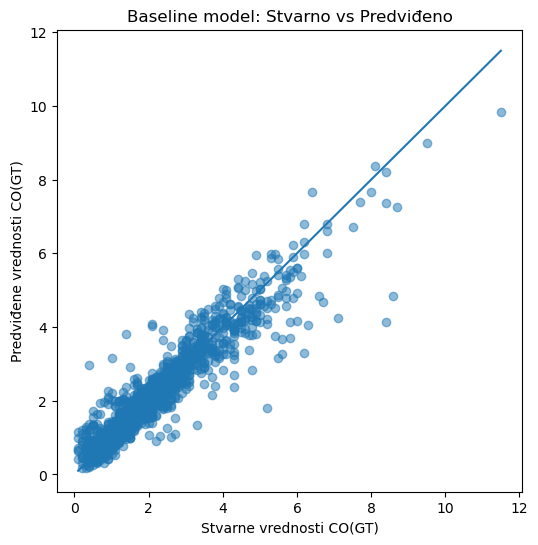

In [237]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_base, y_pred_base, alpha=0.5)

plt.xlabel("Stvarne vrednosti CO(GT)")
plt.ylabel("Predviđene vrednosti CO(GT)")
plt.title("Baseline model: Stvarno vs Predviđeno")

plt.plot(
    [y_test_base.min(), y_test_base.max()],
    [y_test_base.min(), y_test_base.max()]
)

plt.show()

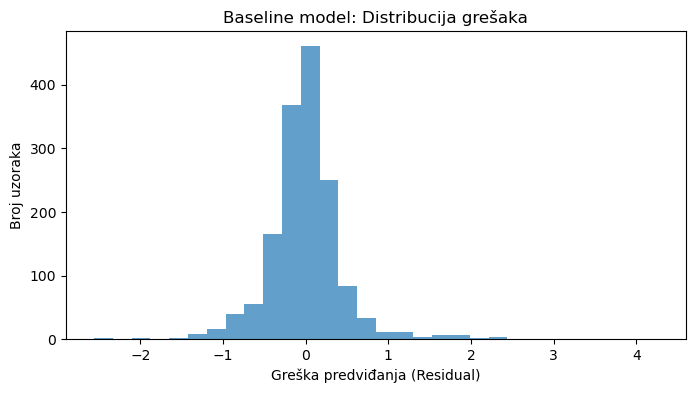

In [238]:
residuals = y_test_base - y_pred_base

plt.figure(figsize=(8,4))
plt.hist(residuals, bins=30, alpha=0.7)

plt.xlabel("Greška predviđanja (Residual)")
plt.ylabel("Broj uzoraka")
plt.title("Baseline model: Distribucija grešaka")
plt.show()

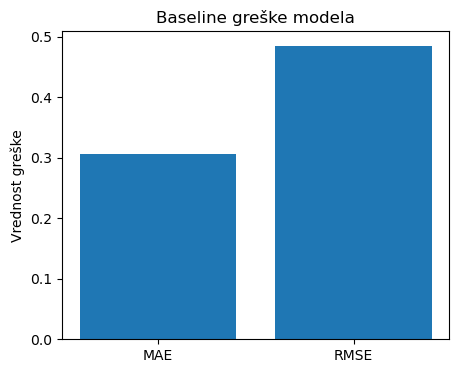

In [239]:
plt.figure(figsize=(5,4))
plt.bar(["MAE", "RMSE"], [mae_base, rmse_base])
plt.title("Baseline greške modela")
plt.ylabel("Vrednost greške")
plt.show()

## Tretman nedostajućih vrednosti (sentinel -200)

Uzorci kod kojih ciljna promenljiva ima sentinel vrednost (-200) ne mogu se koristiti za treniranje modela, jer model ne može da uči na neispravnim ciljnim vrednostima. 
Zbog toga se takvi uzorci uklanjaju.


In [80]:
df_missing = df.copy()
df_original = df.copy()

(df_missing == -200).sum().sum()

(df_missing.select_dtypes(include=["number"]) == -200).sum().sum()

np.int64(16701)

In [81]:
(df_missing == -200).sum().sort_values(ascending=False)

NMHC(GT)         8443
CO(GT)           1683
NO2(GT)          1642
NOx(GT)          1639
PT08.S1(CO)       366
C6H6(GT)          366
PT08.S2(NMHC)     366
PT08.S3(NOx)      366
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64

In [82]:
df_missing.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [83]:
num_cols = df_missing.select_dtypes(include=["number"]).columns

df_missing[num_cols] = df_missing[num_cols].replace(-200, np.nan)

df_missing.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [84]:
(df_missing == -200).sum().sort_values(ascending=False)

CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64

In [85]:
(df_missing.select_dtypes(include=["number"]) == -200).sum().sum()

np.int64(0)

Ukupno: 9471
Zadržano: 7788
Uklonjeno: 1683


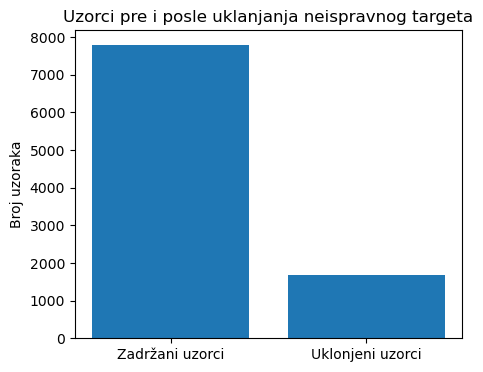

In [86]:
total_samples = len(df_original)

remaining_samples = (df_original["CO(GT)"] != -200).sum()

removed_samples = total_samples - remaining_samples

print("Ukupno:", total_samples)
print("Zadržano:", remaining_samples)
print("Uklonjeno:", removed_samples)

plt.figure(figsize=(5, 4))
plt.bar(
    ["Zadržani uzorci", "Uklonjeni uzorci"],
    [remaining_samples, removed_samples]
)
plt.ylabel("Broj uzoraka")
plt.title("Uzorci pre i posle uklanjanja neispravnog targeta")
plt.show()


In [87]:
(df_missing == -200).sum().sum()

np.int64(0)

## Tretman nedostajućih vrednosti NaN

U korišćenom skupu podataka nedostajuće vrednosti nisu obeležene standardnom `NaN` oznakom, već su predstavljene vrednošću **-200**.
Ovakav način obeležavanja je specifičan za originalni UCI Air Quality skup podataka.

Kako bi se omogućila pravilna obrada podataka i primena algoritama mašinskog učenja, neophodno je:
- identifikovati ovakve vrednosti,
- zameniti ih standardnom `NaN` oznakom,
- kvantifikovati obim problema (broj nedostajućih vrednosti po kolonama).

U ovoj fazi se samo pripremaju podaci za dalje korake.

In [92]:
df_missing.dtypes

CO(GT)           float64
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
dtype: object

In [93]:
missing_counts = df_missing.isna().sum().sort_values(ascending=False)
missing_counts

NMHC(GT)         8557
CO(GT)           1797
NO2(GT)          1756
NOx(GT)          1753
PT08.S1(CO)       480
C6H6(GT)          480
PT08.S2(NMHC)     480
PT08.S3(NOx)      480
PT08.S4(NO2)      480
PT08.S5(O3)       480
T                 480
RH                480
AH                480
dtype: int64

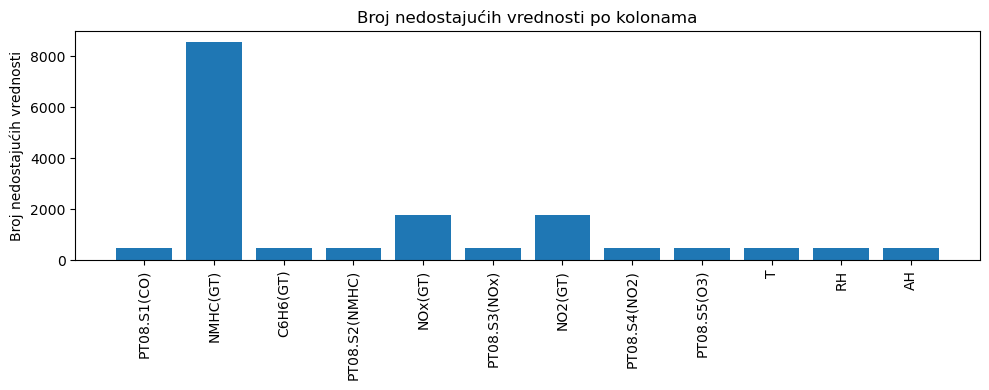

In [88]:
num_cols = df_missing.select_dtypes(include=["number"]).columns
num_cols = num_cols.drop("CO(GT)", errors="ignore")

missing_counts = df_missing[num_cols].isna().sum()

missing_counts = missing_counts[missing_counts > 0]

plt.figure(figsize=(10, 4))
plt.bar(missing_counts.index, missing_counts.values)
plt.xticks(rotation=90)
plt.ylabel("Broj nedostajućih vrednosti")
plt.title("Broj nedostajućih vrednosti po kolonama")
plt.tight_layout()
plt.show()

In [94]:
missing_percentage = (missing_counts / len(df_missing)) * 100
missing_percentage

NMHC(GT)         90.349488
CO(GT)           18.973709
NO2(GT)          18.540809
NOx(GT)          18.509133
PT08.S1(CO)       5.068103
C6H6(GT)          5.068103
PT08.S2(NMHC)     5.068103
PT08.S3(NOx)      5.068103
PT08.S4(NO2)      5.068103
PT08.S5(O3)       5.068103
T                 5.068103
RH                5.068103
AH                5.068103
dtype: float64

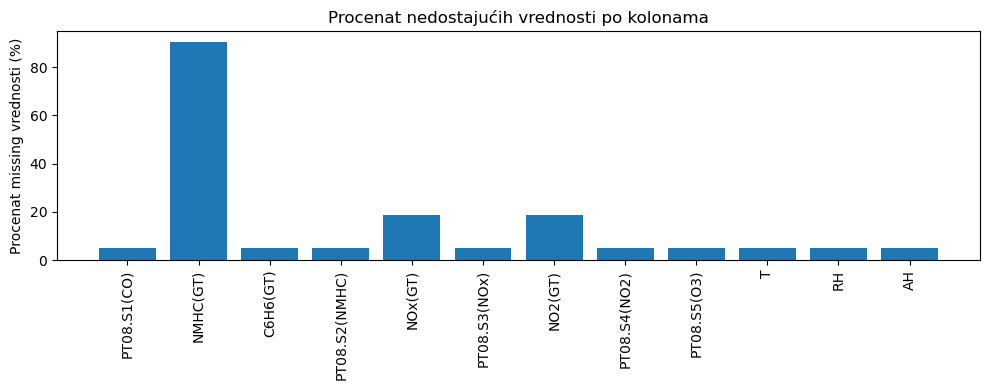

In [89]:
missing_percentage = (missing_counts / len(df_missing)) * 100

plt.figure(figsize=(10, 4))
plt.bar(missing_percentage.index, missing_percentage.values)
plt.xticks(rotation=90)
plt.ylabel("Procenat missing vrednosti (%)")
plt.title("Procenat nedostajućih vrednosti po kolonama")
plt.tight_layout()
plt.show()

In [100]:
X = df_missing.drop(columns=["CO(GT)"])
y = df_missing["CO(GT)"]

mask_y = y.notna()
X = X[mask_y].reset_index(drop=True)
y = y[mask_y].reset_index(drop=True)

print("Preostalo uzoraka:", len(y))
print("NaN u y:", y.isna().sum())

Preostalo uzoraka: 7674
NaN u y: 0


In [104]:
y.isna().sum()

np.int64(0)

In [105]:
y.head()

0    2.6
1    2.0
2    2.2
3    2.2
4    1.6
Name: CO(GT), dtype: float64

In [119]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((6139, 12), (1535, 12))

## Mean imputacija

In [121]:
model_mean = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("regressor", LinearRegression())
])


model_mean.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer()),
                ('regressor', LinearRegression())])

In [107]:
y_pred_mean = model_mean.predict(X_test)

y_pred_mean

array([4.587066  , 1.21236333, 3.37791262, ..., 0.69990415, 0.92978323,
       2.20883099])

In [273]:
mae_mean = mean_absolute_error(y_test, y_pred_mean)
rmse_mean = mean_squared_error(y_test, y_pred_mean)
r2_mean = r2_score(y_test, y_pred_mean)

print("Rezultati nakon Mean:")
print("MAE:", mae_mean)
print("RMSE:", rmse_mean)
print("R2:", r2_mean)

Rezultati nakon Mean:
MAE: 0.3060480080142417
RMSE: 0.22758402743979728
R2: 0.890735755862727


- RMSE se značajno smanjio, što ukazuje da popunjavanje nedostajućih vrednosti doprinosi stabilnijem učenju modela.
- MAE ostaje približno isto, što znači da prosečna greška nije mnogo promenjena, ali su ekstremne greške smanjene.

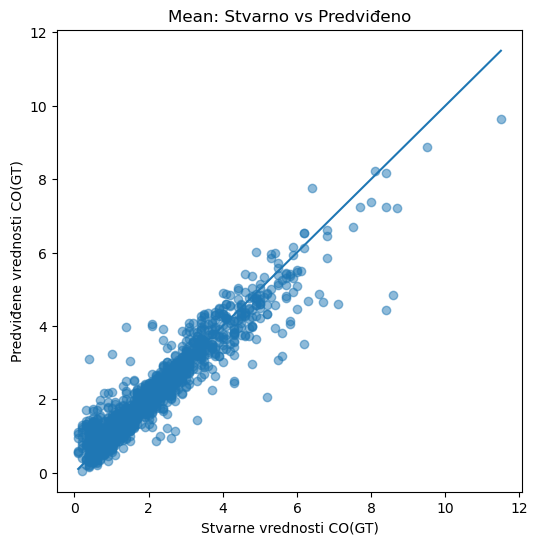

In [272]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_mean, alpha=0.5)

plt.xlabel("Stvarne vrednosti CO(GT)")
plt.ylabel("Predviđene vrednosti CO(GT)")
plt.title("Mean: Stvarno vs Predviđeno")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

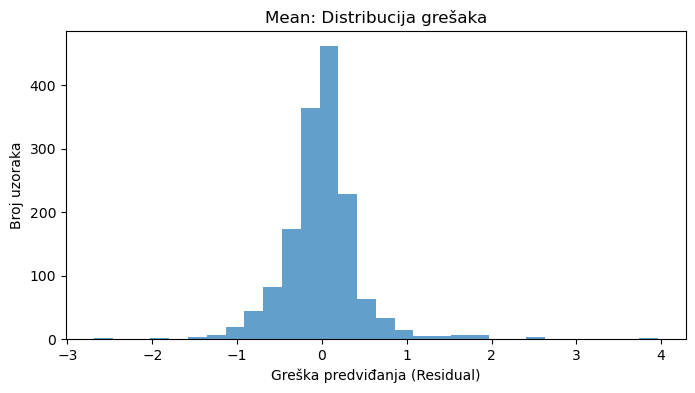

In [271]:
residuals_mean = y_test - y_pred_mean

plt.figure(figsize=(8,4))
plt.hist(residuals_mean, bins=30, alpha=0.7)

plt.xlabel("Greška predviđanja (Residual)")
plt.ylabel("Broj uzoraka")
plt.title("Mean: Distribucija grešaka")
plt.show()

In [114]:
mae = mean_absolute_error(y_test, y_pred_mean)

mse = mean_squared_error(y_test, y_pred_mean)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred_mean)

In [270]:
results_mean = pd.DataFrame({
    "Model": ["Baseline", "Mean"],
    "MAE": [mae, mae_mean],
    "RMSE": [rmse, rmse_mean],
    "R2": [r2, r2_mean]
})

results_mean

,Model,MAE,RMSE,R2
0,Baseline,0.306048,0.477058,0.890736
1,Mean,0.306048,0.227584,0.890736


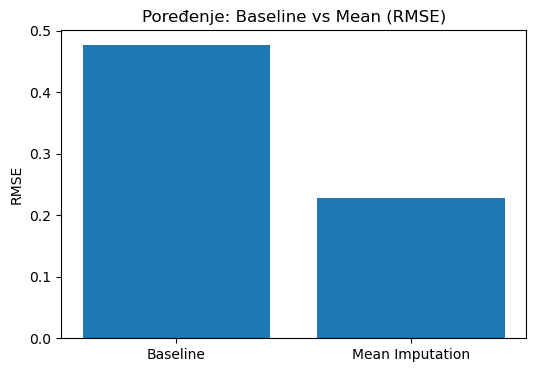

In [267]:
plt.figure(figsize=(6, 4))
plt.bar(results_mean["Model"], results_mean["RMSE"])
plt.ylabel("RMSE")
plt.title("Poređenje: Baseline vs Mean (RMSE)")
plt.show()

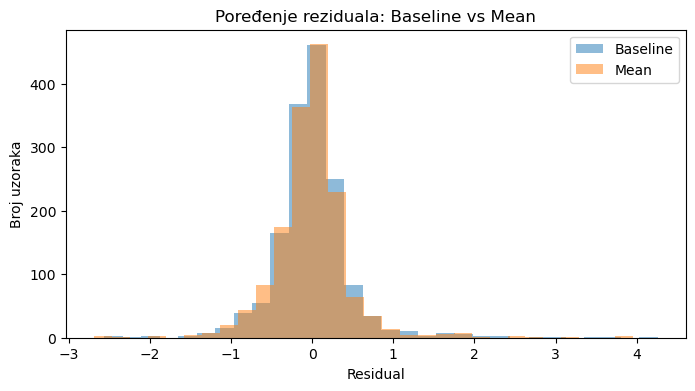

In [269]:
plt.figure(figsize=(8,4))

plt.hist(y_test_base - y_pred_base, bins=30, alpha=0.5, label="Baseline")
plt.hist(y_test - y_pred_mean, bins=30, alpha=0.5, label="Mean")

plt.xlabel("Residual")
plt.ylabel("Broj uzoraka")
plt.title("Poređenje reziduala: Baseline vs Mean")
plt.legend()
plt.show()

## KNN imputacija

In [242]:
model_knn = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("regressor", LinearRegression())
])

model_knn.fit(X_train, y_train)

Pipeline(steps=[('imputer', KNNImputer()), ('regressor', LinearRegression())])

In [266]:
y_pred_knn = model_knn.predict(X_test)

mae_knn = mean_absolute_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_knn = r2_score(y_test, y_pred_knn)

print("Rezultati nakon KNN:")
print("MAE:", mae_knn)
print("RMSE:", rmse_knn)
print("R2:", r2_knn)

Rezultati nakon KNN:
MAE: 0.28307648241187694
RMSE: 0.4436058197630522
R2: 0.9055219855980989


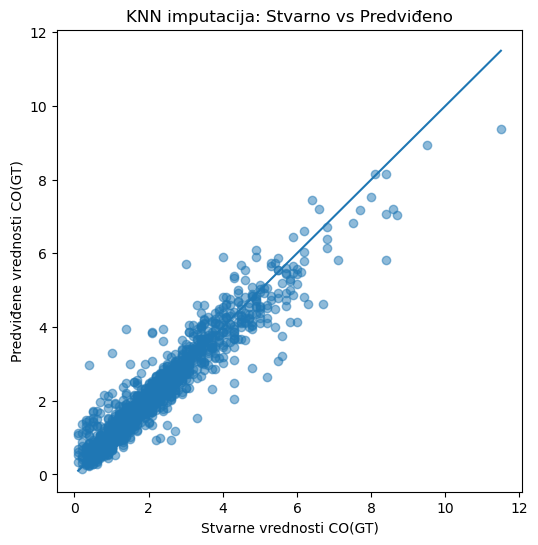

In [252]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_knn, alpha=0.5)

plt.xlabel("Stvarne vrednosti CO(GT)")
plt.ylabel("Predviđene vrednosti CO(GT)")
plt.title("KNN imputacija: Stvarno vs Predviđeno")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

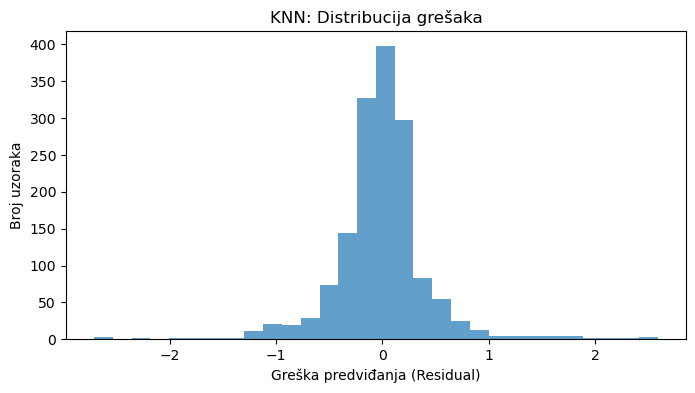

In [274]:
residuals_knn = y_test - y_pred_knn

plt.figure(figsize=(8,4))
plt.hist(residuals_knn, bins=30, alpha=0.7)

plt.xlabel("Greška predviđanja (Residual)")
plt.ylabel("Broj uzoraka")
plt.title("KNN: Distribucija grešaka")
plt.show()

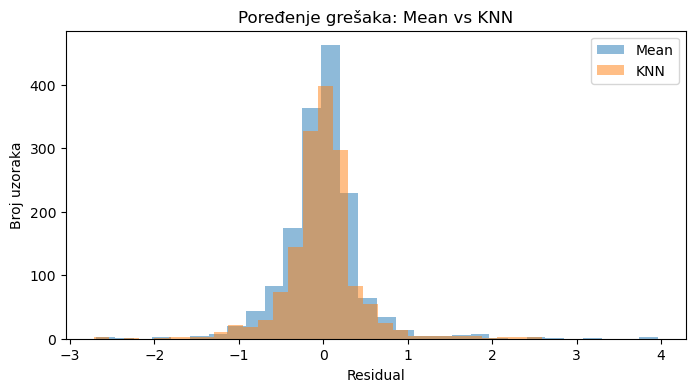

In [276]:
plt.figure(figsize=(8,4))

plt.hist(y_test - y_pred_mean, bins=30, alpha=0.5, label="Mean")
plt.hist(y_test - y_pred_knn, bins=30, alpha=0.5, label="KNN")

plt.xlabel("Residual")
plt.ylabel("Broj uzoraka")
plt.title("Poređenje grešaka: Mean vs KNN")
plt.legend()
plt.show()

## Median imputacija

In [287]:
model_median = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("regressor", LinearRegression())
])

In [288]:
model_median.fit(X_train, y_train)

y_pred_median = model_median.predict(X_test)

mae_median = mean_absolute_error(y_test, y_pred_median)
rmse_median = np.sqrt(mean_squared_error(y_test, y_pred_median))
r2_median = r2_score(y_test, y_pred_median)

print("Rezultati nakon Median imputacije:")
print("MAE:", mae_median)
print("RMSE:", rmse_median)
print("R2:", r2_median)

Rezultati nakon Median imputacije:
MAE: 0.29997786891867295
RMSE: 0.4717743921115775
R2: 0.8931424987310861


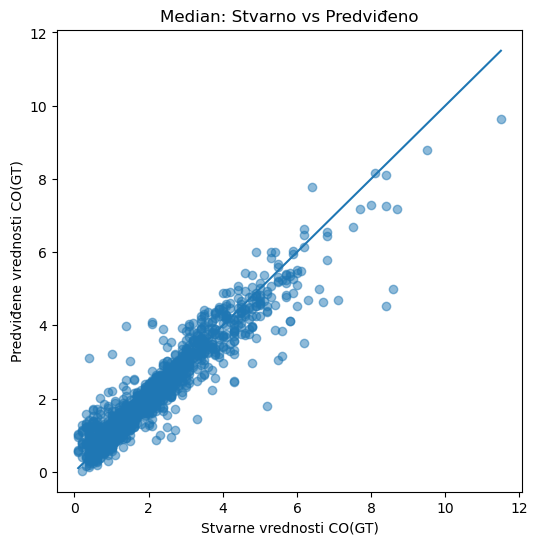

In [291]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_median, alpha=0.5)

plt.xlabel("Stvarne vrednosti CO(GT)")
plt.ylabel("Predviđene vrednosti CO(GT)")
plt.title("Median: Stvarno vs Predviđeno")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

In [ ]:
residuals_median = y_test - y_pred_median

plt.figure(figsize=(8,4))
plt.hist(residuals_median, bins=30, alpha=0.7)

plt.xlabel("Greška predviđanja (Residual)")
plt.ylabel("Broj uzoraka")
plt.title("Median imputacija: Distribucija grešaka")
plt.show()


## Poređenje modela

In [289]:
results_all = pd.DataFrame({
    "Model": ["Baseline", "Mean", "Median", "KNN"],
    "RMSE": [rmse_base, rmse_mean, rmse_median, rmse_knn],
    "MAE":  [mae_base, mae_mean, mae_median, mae_knn],
    "R2":   [r2_base, r2_mean, r2_median, r2_knn]
})

results_all

,Model,RMSE,MAE,R2
0,Baseline,0.484602,0.305625,0.887253
1,Mean,0.227584,0.306048,0.890736
2,Median,0.471774,0.299978,0.893142
3,KNN,0.443606,0.283076,0.905522


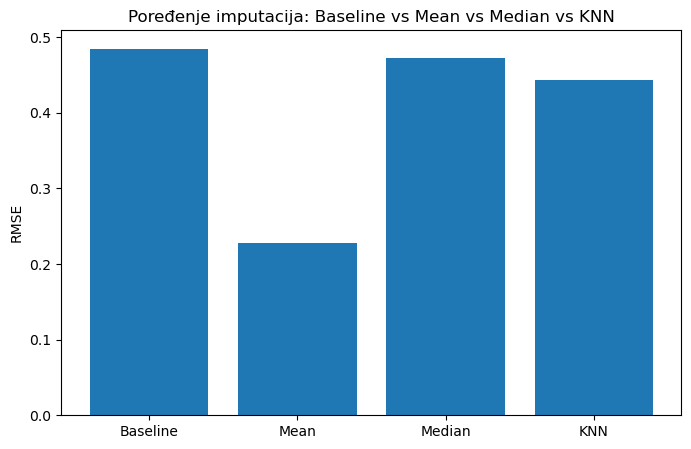

In [290]:
plt.figure(figsize=(8,5))
plt.bar(results_all["Model"], results_all["RMSE"])
plt.ylabel("RMSE")
plt.title("Poređenje imputacija: Baseline vs Mean vs Median vs KNN")
plt.show()